# Part 1 
Verification and exploration of the code

In [1]:
import sys, random
import pandas as pd
sys.path.insert(0, '.')

from simulation import *

random.seed(0)

In [2]:
PATIENT_TYPES = {1: 'elective', 2: 'urgent'}
SCAN_TYPES    = {0: 'brain', 1: 'lumbar', 2: 'cervical', 3: 'abdomen', 4: 'other'}
DAYS          = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat'}  # dict!

def patient_repr(p) -> str:
    ptype = PATIENT_TYPES.get(p.patientType, '?')
    stype = SCAN_TYPES.get(p.scanType, '?') if p.patientType == 2 else '-'
    call  = f"W{p.callWeek} {DAYS.get(p.callDay,'?')} {p.callTime:.2f}h"
    appt  = 'unscheduled' if p.scanWeek == -1 else \
            f"W{p.scanWeek} {DAYS.get(p.scanDay,'?')} slot={p.slotNr} @{p.appTime:.2f}h"
    scan  = f"scanTime={p.scanTime:.2f}h" if p.scanTime != -1 else 'not yet scanned'
    tard  = f"tard={p.tardiness*60:+.1f}min"
    ns    = ' NO-SHOW' if p.isNoShow else ''
    return f"[{p.nr:>4}] {ptype:<8} {stype:<8}  arrived: {call:<22}  appt: {appt:<30}  {scan:<22}  {tard}{ns}"

def print_patients(patients, limit=None):
    shown = patients[:limit] if limit else patients
    for p in shown:
        print(patient_repr(p))
    if limit and len(patients) > limit:
        print(f'  ... ({len(patients) - limit} more)')

SLOT_LABELS = {0: '.', 1: 'E', 2: 'U', 3: 'T'}
DAY_NAMES = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']  # renamed to avoid overwriting DAYS dict

def print_week_schedule_compact(sim):
    print(f"{'slot':>4}  {'time':>5}  " + " ".join(f"{d:>3}" for d in DAY_NAMES))
    for s in range(sim.S):
        slot0 = sim.weekSchedule[0][s]
        if not hasattr(slot0, 'startTime'):
            print("weekSchedule not populated yet — call sim.setWeekSchedule() first")
            return
        time_str = f"{slot0.startTime:.2f}h"
        labels = " ".join(f"{SLOT_LABELS.get(sim.weekSchedule[d][s].slotType, '?'):>3}" for d in range(sim.D))
        print(f"{s:>4}  {time_str:>5}  {labels}")


In [7]:
#set view and seed
n_view = 150
random.seed(0)

#make sim
sim = Simulation("../input-S1-14.txt", 100, 100, 2)

#set schedule and visualize
sim.setWeekSchedule()
print_week_schedule_compact(sim)

#need to reset system before generating patients (see main)
sim.resetSystem()

#generate patients and visualize (before and after scheduling)
sim.generatePatients()
print_patients(sim.patients, limit=n_view)
sim.schedulePatients()
print_patients(sim.patients, limit=n_view)

slot   time  Mon Tue Wed Thu Fri Sat
   0  8.00h    E   E   E   E   E   E
   1  8.25h    E   E   E   E   E   E
   2  8.50h    E   E   E   E   E   E
   3  8.75h    E   E   E   E   E   E
   4  9.00h    E   E   E   E   E   E
   5  9.25h    E   E   E   E   E   E
   6  9.50h    E   E   E   E   E   E
   7  9.75h    E   E   E   E   E   E
   8  10.00h    E   E   E   E   E   E
   9  10.25h    E   E   E   E   E   E
  10  10.50h    E   E   E   E   E   E
  11  10.75h    E   E   E   E   E   E
  12  11.00h    E   E   E   E   E   E
  13  11.25h    E   E   E   E   E   E
  14  11.50h    U   U   U   E   U   E
  15  11.75h    U   U   U   U   U   U
  16  13.00h    E   E   E   .   E   .
  17  13.25h    E   E   E   .   E   .
  18  13.50h    E   E   E   .   E   .
  19  13.75h    E   E   E   .   E   .
  20  14.00h    E   E   E   .   E   .
  21  14.25h    E   E   E   .   E   .
  22  14.50h    E   E   E   .   E   .
  23  14.75h    E   E   E   .   E   .
  24  15.00h    E   E   E   .   E   .
  25  15.25h    E   E

In [8]:
overflow = [
    p for p in sim.patients
    if p.patientType == 2
    and p.scanDay in (3, 5)
    and p.appTime != -1
    and p.appTime >= 13
]

print(f"Urgent patients scheduled past 13:00 on Thu/Sat: {len(overflow)}")
print_patients(overflow)


Urgent patients scheduled past 13:00 on Thu/Sat: 95
[ 137] urgent   brain     arrived: W0 Sat 9.98h            appt: W0 Sat slot=32 @17.00h          not yet scanned         tard=+0.0min
[ 138] urgent   abdomen   arrived: W0 Sat 10.27h           appt: W0 Sat slot=33 @17.25h          not yet scanned         tard=+0.0min
[ 422] urgent   brain     arrived: W2 Thu 11.30h           appt: W2 Thu slot=32 @17.00h          not yet scanned         tard=+0.0min
[ 742] urgent   brain     arrived: W4 Thu 11.87h           appt: W4 Thu slot=32 @17.00h          not yet scanned         tard=+0.0min
[1063] urgent   brain     arrived: W6 Sat 10.88h           appt: W6 Sat slot=32 @17.00h          not yet scanned         tard=+0.0min
[1178] urgent   brain     arrived: W7 Thu 11.89h           appt: W7 Thu slot=32 @17.00h          not yet scanned         tard=+0.0min
[1316] urgent   brain     arrived: W8 Thu 10.20h           appt: W8 Thu slot=32 @17.00h          not yet scanned         tard=+0.0min
[1347] urg

# Part 2
Runs some initial detailed simulations to get to know the system

In [9]:
def run_simulation_detailed(filename, W, R, rule):
    """
    Same as run_simulation() but saves per-replication and per-week metrics.
    Returns:
        replications: list of dicts, one per replication
        averages: dict of overall averages
    """
    sim = Simulation(filename, W, R, rule)
    sim.setWeekSchedule()

    replications = []

    for r in range(R):
        sim.resetSystem()
        random.seed(r)
        sim.runOneSimulation()

        ov = sim.avgElectiveAppWT * sim.weightEl + sim.avgUrgentScanWt * sim.weightUr

        replications.append({
            'replication':  r,
            'elAppWT':      sim.avgElectiveAppWT,
            'elScanWT':     sim.avgElectiveScanWT,
            'urScanWT':     sim.avgUrgentScanWt,
            'OT':           sim.avgOT,
            'OV':           ov,
            # week-by-week moving averages within this replication:
            'movAvg_elAppWT':  sim.movingAvgElectiveAppWT[:],
            'movAvg_elScanWT': sim.movingAvgElectiveScanWT[:],
            'movAvg_urScanWT': sim.movingAvgUrgentScanWT[:],
            'movAvg_OT':       sim.movingAvgOT[:],
        })

    df_rep = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('movAvg')}
                            for r in replications])

    averages = {
        'elAppWT':  df_rep['elAppWT'].mean(),
        'elScanWT': df_rep['elScanWT'].mean(),
        'urScanWT': df_rep['urScanWT'].mean(),
        'OT':       df_rep['OT'].mean(),
        'OV':       df_rep['OV'].mean(),
    }

    return replications, df_rep, averages

In [10]:
replications, df_rep, averages = run_simulation_detailed('../input-S1-14.txt', W=200, R=10, rule=1)
df_rep.describe()

,replication,elAppWT,elScanWT,urScanWT,OT,OV
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,4.50000,22.817974,0.082889,2.917096,0.798047,0.459943
std,3.02765,4.141035,0.000559,0.026603,0.047007,0.026180
min,0.00000,18.948892,0.082248,2.881074,0.732222,0.432910
25%,2.25000,19.849615,0.082543,2.899786,0.773310,0.441465
50%,4.50000,22.210317,0.082858,2.918006,0.789624,0.455589
75%,6.75000,23.981663,0.082994,2.921891,0.819386,0.468879
max,9.00000,33.060300,0.084140,2.976514,0.901870,0.523199


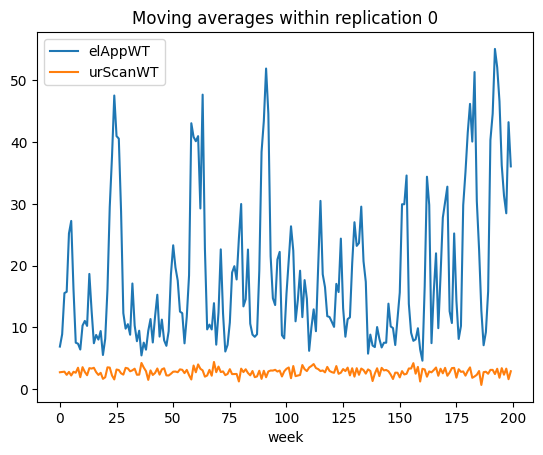

In [11]:
# moving average of one replication (e.g. rep 0) to see warm-up behaviour
import matplotlib.pyplot as plt

i_repl = 0

rep0 = replications[i_repl]
plt.plot(rep0['movAvg_elAppWT'], label='elAppWT')
plt.plot(rep0['movAvg_urScanWT'], label='urScanWT')
plt.xlabel('week')
plt.legend()
plt.title(f'Moving averages within replication {i_repl}')
plt.show()

# Part 3
Even more detail for a single replication

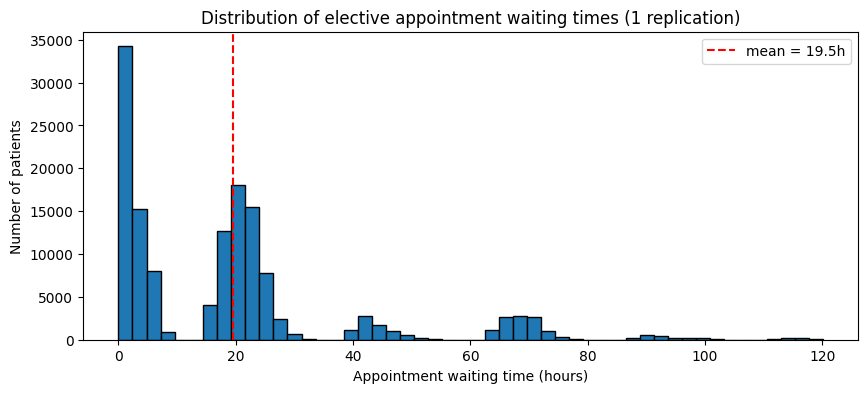

Min:  0.0h
Max:  120.1h
Mean: 19.5h


In [17]:
# collect all individual elective patient appWT values from one replication
sim2 = Simulation('../input-S1-14.txt', W=1000, R=1, rule=1)
sim2.setWeekSchedule()
sim2.resetSystem()
random.seed(0)
sim2.generatePatients()
sim2.schedulePatients()

elective_waits = [
    p.getAppWT()
    for p in sim2.patients
    if p.patientType == 1 and p.scanWeek != -1
]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(elective_waits, bins=50, edgecolor='black')
plt.xlabel('Appointment waiting time (hours)')
plt.ylabel('Number of patients')
plt.title('Distribution of elective appointment waiting times (1 replication)')
plt.axvline(sum(elective_waits)/len(elective_waits), color='red', linestyle='--', label=f'mean = {sum(elective_waits)/len(elective_waits):.1f}h')
plt.legend()
plt.show()

print(f"Min:  {min(elective_waits):.1f}h")
print(f"Max:  {max(elective_waits):.1f}h")
print(f"Mean: {sum(elective_waits)/len(elective_waits):.1f}h")

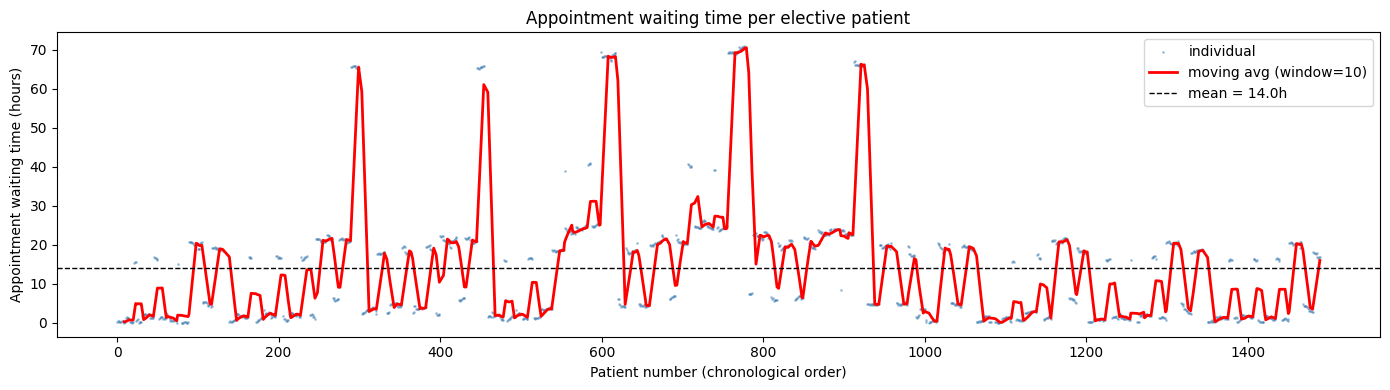

In [ ]:
import numpy as np

elective_patients = [
    p for p in sim2.patients
    if p.patientType == 1 and p.scanWeek != -1
]

elective_patients.sort(key=lambda p: p.nr)

nrs   = [p.nr for p in elective_patients]
waits = [p.getAppWT() for p in elective_patients]

window = 10
moving_avg = np.convolve(waits, np.ones(window)/window, mode='valid')
moving_avg_nrs = nrs[window-1:]  # align x-axis to end of each window

plt.figure(figsize=(14, 4))
plt.scatter(nrs, waits, alpha=0.4, s=1, color='steelblue', label='individual')
plt.plot(moving_avg_nrs, moving_avg, color='red', linewidth=2, label=f'moving avg (window={window})')
plt.axhline(sum(waits)/len(waits), color='black', linestyle='--', linewidth=1, label=f'mean = {sum(waits)/len(waits):.1f}h')
plt.xlabel('Patient number (chronological order)')
plt.ylabel('Appointment waiting time (hours)')
plt.title('Appointment waiting time per elective patient')
plt.legend()
plt.tight_layout()
plt.show()


# Part 4
Get real results now